In [2]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
import seaborn as sns
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
base_dir = os.getcwd()
runs_str = "run-ON"

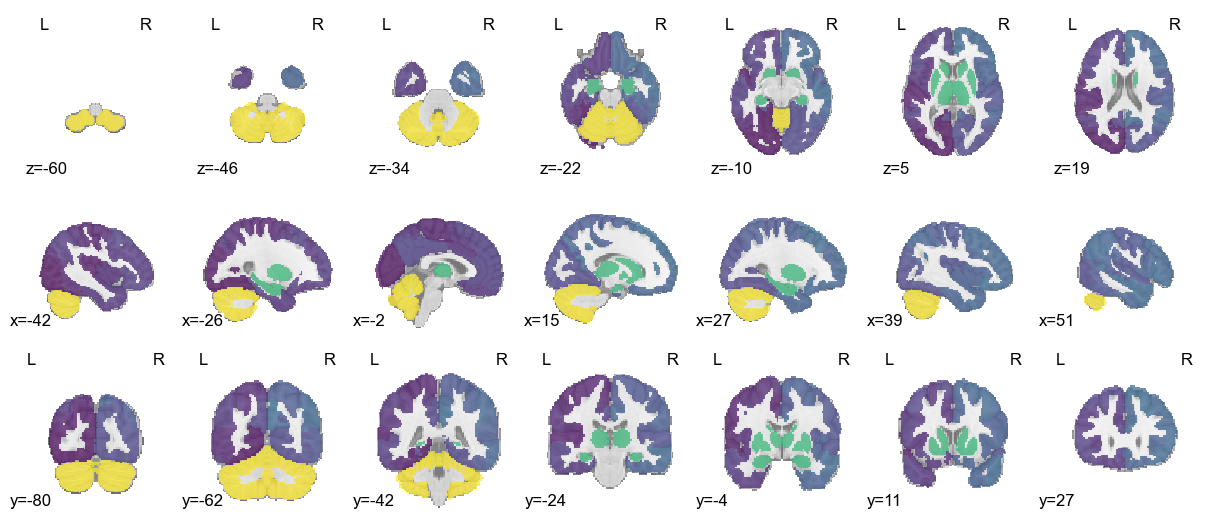

In [4]:
atlas_filename = os.path.join(base_dir, "templates", "atlases","KH_atlas", "atlas_combined_tpl-MNI152NLin2009cAsym_res-02_T1w.nii.gz")

atlas_masker = NiftiLabelsMasker(labels_img=atlas_filename, mask_img=None, standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)
atlas_masker.fit()

plotting.plot_roi(atlas_filename, display_mode="mosaic", cmap="viridis",)

In [5]:
k=7
CAP_LIST = [f"CAP{i + 1}" for i in np.arange(k)]
plots_dir = os.path.join(base_dir, "plots", "corr_mats", f"nclust-{k}")
os.makedirs(plots_dir, exist_ok=True)

# Load CAP data
cap_file = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                            f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}.nii.gz')
cap_img = nib.load(cap_file)

# Transform data using masker
cap_data_masked = atlas_masker.transform(cap_img)  # Will be (n_caps, n_voxels)

## Pearson similarity

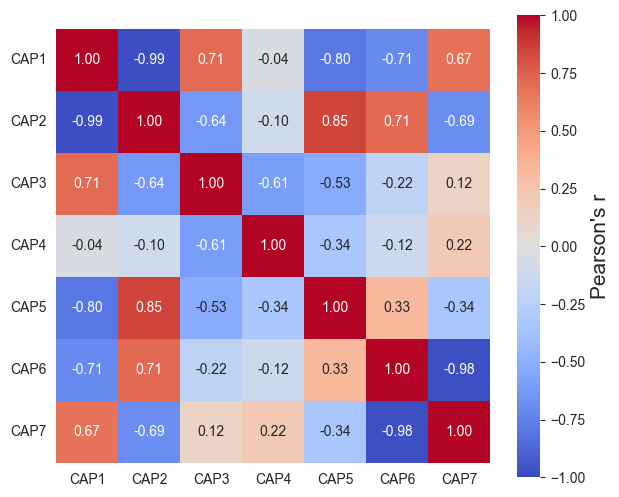

In [6]:
# Calculate correlation matrix
corr_mat = np.corrcoef(cap_data_masked)

fig, ax = plt.subplots(figsize=(7, 6))

heatmap = sns.heatmap(corr_mat, cmap="coolwarm", vmax=1, vmin=-1, center=0,
                square=True, annot=True, fmt=".2f", ax=ax)

cbar = heatmap.collections[0].colorbar
cbar.set_label("Pearson's r", rotation=90, fontsize=15)
ax.set_xticklabels(CAP_LIST, rotation=0)
ax.set_yticklabels(CAP_LIST, rotation=0)

plt.savefig(os.path.join(plots_dir, f"pearson_corr_mat_nclust-{k}"), dpi=400)


## Spearman similarity

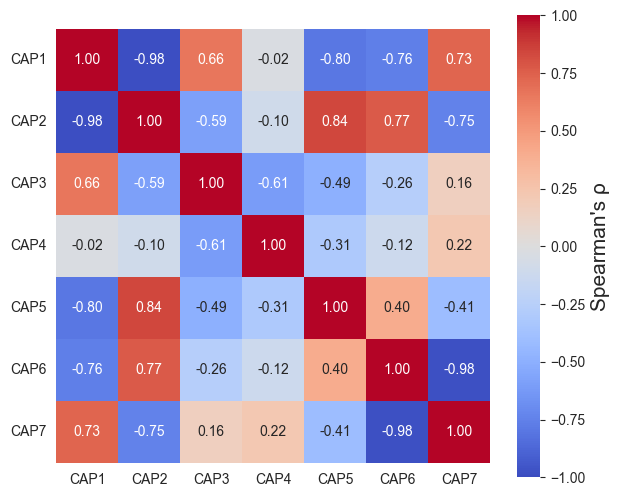

In [7]:
from scipy.stats import spearmanr
# Calculate correlation matrix
corr_mat = spearmanr(cap_data_masked.T).correlation

fig, ax = plt.subplots(figsize=(7, 6))

heatmap = sns.heatmap(corr_mat, cmap="coolwarm", vmax=1, vmin=-1, center=0,
                square=True, annot=True, fmt=".2f", ax=ax)
cbar = heatmap.collections[0].colorbar
cbar.set_label("Spearman's ρ", rotation=90, fontsize=15)

ax.set_xticklabels(CAP_LIST, rotation=0)
ax.set_yticklabels(CAP_LIST, rotation=0)
#ax.set_title("Spearman Correlation Matrix")
plt.savefig(os.path.join(plots_dir, f"spearman_corr_mat_nclust-{k}"), dpi=400)

## Cosine similarity

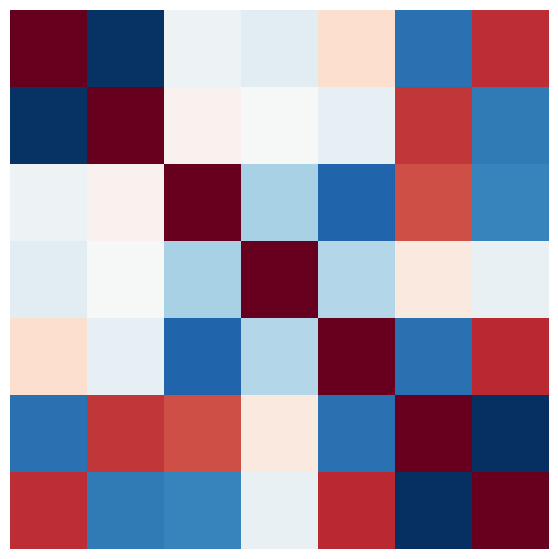

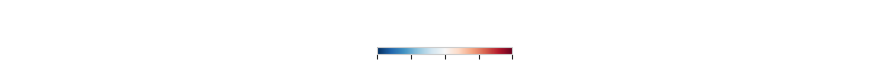

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.cm as cm

cmap = "RdBu_r"  # or "PuOr", "BrBG"
#cmap = "RdYlGn"
#cmap = "PuOr"
#cmap = "BrBG"
empty_labels = ["", "", "", "", "", "", ""]

corr_mat = cosine_similarity(cap_data_masked)

# Create the heatmap without annotations and with viridis colormap
fig, ax = plt.subplots(figsize=(7, 7))

heatmap = sns.heatmap(corr_mat, cmap=cmap, vmax=1, vmin=-1, center=0,
                square=True, annot=False, ax=ax, cbar=False)

ax.set_xticklabels(empty_labels)
ax.set_yticklabels(empty_labels)

# Save the main heatmap
plt.savefig(os.path.join(plots_dir, f"cosine_corr_mat_nclust-{k}"), dpi=500, bbox_inches='tight')

# Create separate legend/colorbar
fig_legend, ax_legend = plt.subplots(figsize=(9, 0.75))
ax_legend.axis('off')

# Create a colorbar manually
from matplotlib.colors import Normalize
import matplotlib.cm as cm

norm = Normalize(vmin=-1, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax_legend, orientation='horizontal')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["", "", "", "", ""])
cbar.ax.tick_params(labelsize=42)
cbar.set_label('', fontsize=20)
plt.tight_layout()

# Save the legend separately
plt.savefig(os.path.join(plots_dir, f"cosine_corr_mat_legend_nclust-{k}"), dpi=500, bbox_inches='tight')